In [2]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
from pyreadr import read_r
from sklearn.preprocessing import StandardScaler

from clean import clean_data, preprocess_data, get_question_columns
from models import make_projection
from plots import (plot_response_maps, plot_question_association,
                   plot_three_question_association, plot_pca_variance,
                   plot_geographic_projections, plot_component_maps)

Path("../figs").mkdir(exist_ok=True)


In [3]:
raw_data = pd.read_csv("../data/lingData.txt", sep=r"\s+")
question_data = read_r("../data/question_data.RData")
state_shapes = gpd.read_file("../data/shapefiles")
state_shapes = state_shapes.loc[state_shapes["iso_a2"] == "US"]

raw_data.shape

(47471, 73)

In [4]:
cleaned_data = clean_data(raw_data, question_data, state_shapes)

question_columns = get_question_columns(raw_data)
raw_no_response = raw_data[question_columns] == 0
cleaned_missing = cleaned_data[question_columns].isna()
assert (raw_no_response.values == cleaned_missing.values).all()

cleaned_data.shape

(47471, 74)

In [5]:
answers, respondents = preprocess_data(cleaned_data)

answers.shape

(40061, 67)

In [6]:
questions_answered = cleaned_data[question_columns].notna().sum(axis=1)
has_location = cleaned_data[["latitude", "longitude"]].notna().all(axis=1)
cleaning_audit = pd.Series({
    "Raw respondents": len(raw_data),
    "Raw columns": raw_data.shape[1],
    "Duplicate respondent IDs": cleaned_data["respondent_id"].duplicated().sum(),
    "Answered no questions": (questions_answered == 0).sum(),
    "Answered some questions": ((questions_answered > 0) & (questions_answered < len(question_columns))).sum(),
    "Answered all questions": (questions_answered == len(question_columns)).sum(),
    "Invalid or missing states": cleaned_data["state"].isna().sum(),
    "Missing coordinates": (~has_location).sum(),
    "Location conflicts": cleaned_data["location_conflict"].sum(),
    "Analysis respondents": len(answers),
})
cleaning_audit

Raw respondents              47471
Raw columns                     73
Duplicate respondent IDs         0
Answered no questions         1040
Answered some questions       6370
Answered all questions       40061
Invalid or missing states      159
Missing coordinates           1020
Location conflicts             302
Analysis respondents         40061
dtype: int64

In [7]:
analysis_questions = ["Q066", "Q074", "Q065"]
comparison_answers, comparison_respondents = preprocess_data(
    cleaned_data, questions=analysis_questions
)

comparison_audit = pd.Series({
    "All respondents": len(cleaned_data),
    "Answered Q66 and Q74": cleaned_data[["Q066", "Q074"]].notna().all(axis=1).sum(),
    "Answered all three questions": len(comparison_answers),
    "Excluded from three-question comparison": len(cleaned_data) - len(comparison_answers),
})
comparison_audit


All respondents                            47471
Answered Q66 and Q74                       45984
Answered all three questions               45941
Excluded from three-question comparison     1530
dtype: int64

In [8]:
response_rows = []
for question in analysis_questions:
    counts = cleaned_data[question].value_counts()
    for answer, count in counts.items():
        response_rows.append({
            "question": question,
            "answer": answer,
            "respondents": count,
            "percent": 100 * count / cleaned_data[question].notna().sum(),
        })
response_summary = pd.DataFrame(response_rows)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(response_summary.round(2))


,question,answer,respondents,percent
0,Q066,crawfish,18383,39.87
1,Q066,crayfish,12760,27.68
2,Q066,crawdad,10804,23.43
3,Q066,I have no word for this critter,2159,4.68
4,Q066,other,1882,4.08
5,Q066,mudbug,50,0.11
6,Q066,craw,39,0.08
7,Q066,crowfish,26,0.06
8,Q074,roly poly,15752,34.17
9,Q074,pill bug,6774,14.69


In [9]:
map_responses = {
    "Q066": ["crawfish", "crayfish", "crawdad"],
    "Q074": ["pill bug", "doodle bug", "potato bug", "roly poly", "sow bug"],
    "Q065": ["lightning bug", "firefly", "I use lightning bug and firefly interchangeably"],
}
min_state_respondents = 30

state_rows = []
map_audit_rows = []
for question in analysis_questions:
    map_answers, map_respondents = preprocess_data(
        cleaned_data, questions=[question], drop_location_conflicts=True
    )
    map_data = map_answers.join(map_respondents[["state"]]).dropna(subset=["state"])
    state_counts = map_data.groupby("state", observed=True).size()

    map_audit_rows.append({
        "question": question,
        "answered": cleaned_data[question].notna().sum(),
        "location_conflicts_excluded": (
            cleaned_data[question].notna() & cleaned_data["location_conflict"]
        ).sum(),
        "invalid_states_excluded": map_respondents["state"].isna().sum(),
        "state_cohort": len(map_data),
        "states_below_minimum": (state_counts < min_state_respondents).sum(),
        "minimum_state_respondents": min_state_respondents,
    })
    for response in map_responses[question]:
        response_counts = map_data.loc[map_data[question] == response].groupby("state", observed=True).size()
        for state, total in state_counts.items():
            count = response_counts.get(state, 0)
            state_rows.append({
                "question": question, "answer": response, "state": state,
                "responses": count, "respondents": total,
                "percent": 100 * count / total,
            })

state_summary = pd.DataFrame(state_rows)
mapping_audit = pd.DataFrame(map_audit_rows)
mapping_audit


,question,answered,location_conflicts_excluded,invalid_states_excluded,state_cohort,states_below_minimum,minimum_state_respondents
0,Q066,46103,296,154,45653,0,30
1,Q074,46101,297,153,45651,0,30
2,Q065,46171,297,153,45721,0,30


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


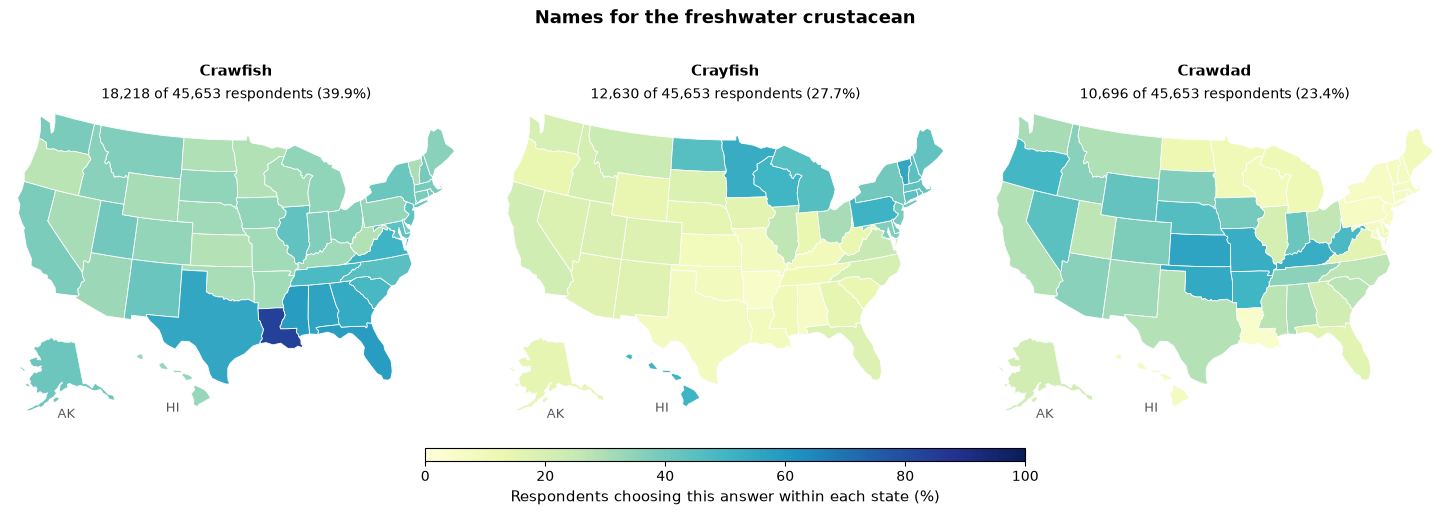

In [10]:
plot_response_maps(state_summary, state_shapes, "Q066", map_responses["Q066"],
                   "Names for the freshwater crustacean",
                   "q66_response_maps", min_respondents=min_state_respondents)


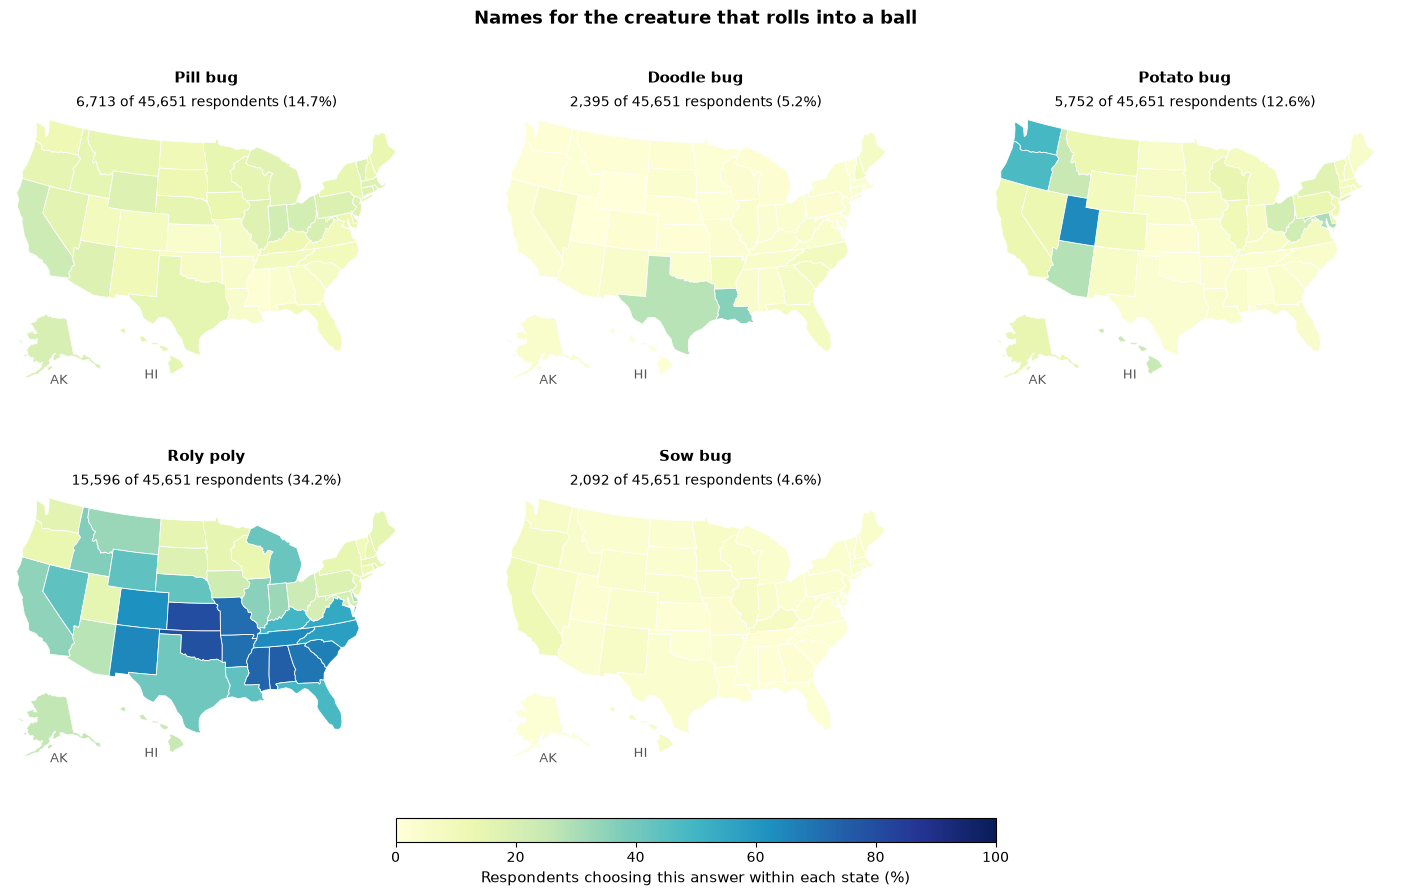

In [11]:
plot_response_maps(state_summary, state_shapes, "Q074", map_responses["Q074"],
                   "Names for the creature that rolls into a ball",
                   "q74_response_maps", min_respondents=min_state_respondents)


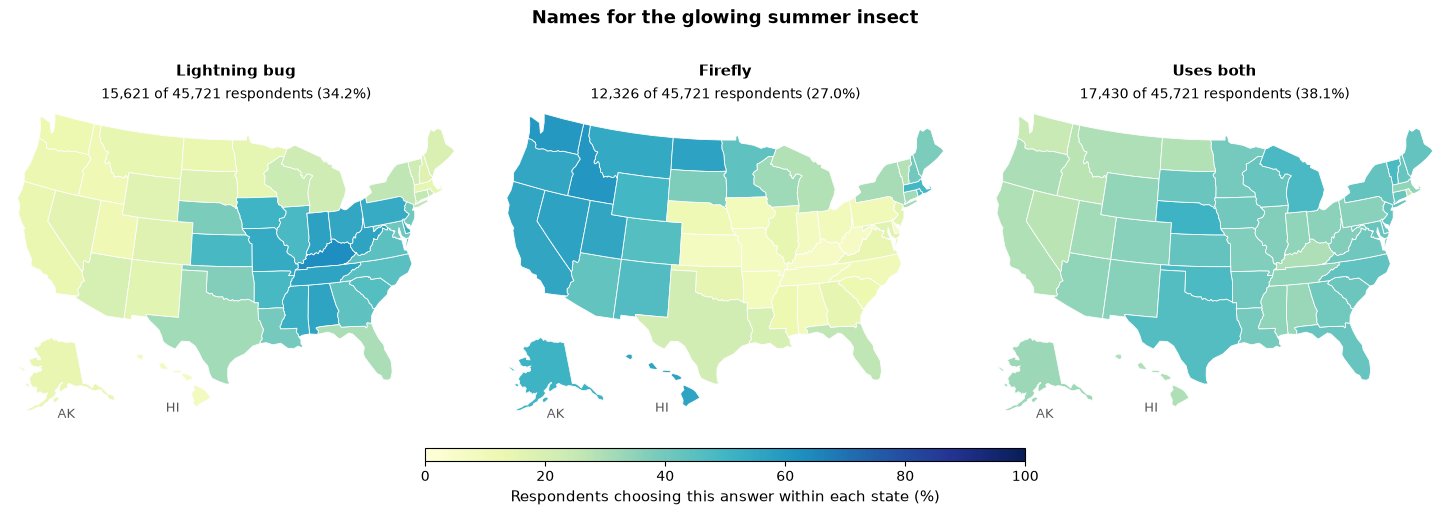

In [12]:
plot_response_maps(state_summary, state_shapes, "Q065", map_responses["Q065"],
                   "Names for the glowing summer insect",
                   "q65_response_maps", min_respondents=min_state_respondents)


In [14]:
q66_order = ["crawfish", "crayfish", "crawdad", "Other responses", "No word"]
q74_order = ["roly poly", "pill bug", "potato bug", "doodle bug", "sow bug",
             "Other responses", "No word", "Don't recognize"]
group_mappings = {}
for question in ["Q066", "Q074"]:
    labels = {}
    for answer in cleaned_data[question].cat.categories:
        if answer in map_responses[question]:
            labels[answer] = answer
        else:
            labels[answer] = "Other responses"
    group_mappings[question] = labels

group_mappings["Q066"]["I have no word for this critter"] = "No word"
group_mappings["Q074"]["I know what this creature is, but have no word for it"] = "No word"
group_mappings["Q074"]["I have no idea what this creature is"] = "Don't recognize"

plot_answers = comparison_answers.copy()
for question, labels in group_mappings.items():
    plot_answers[question] = plot_answers[question].map(labels).astype("object")

grouping_rows = []
for question, labels in group_mappings.items():
    for answer, group in labels.items():
        grouping_rows.append({"question": question, "original_answer": answer, "plot_group": group})
grouping_summary = pd.DataFrame(grouping_rows)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(grouping_summary)


,question,original_answer,plot_group
0,Q066,crawfish,crawfish
1,Q066,crayfish,crayfish
2,Q066,craw,Other responses
3,Q066,crowfish,Other responses
4,Q066,crawdad,crawdad
5,Q066,mudbug,Other responses
6,Q066,I have no word for this critter,No word
7,Q066,other,Other responses
8,Q074,pill bug,pill bug
9,Q074,doodle bug,doodle bug


In [15]:
pair_counts = pd.crosstab(plot_answers["Q066"], plot_answers["Q074"])
pair_counts = pair_counts.reindex(index=q66_order, columns=q74_order, fill_value=0)
pair_row_counts = pair_counts.sum(axis=1)
pair_percentages = 100 * pair_counts.div(pair_row_counts.where(pair_row_counts > 0), axis=0)

q74_baseline = 100 * pair_counts.sum(axis=0) / pair_counts.to_numpy().sum()

assert pair_counts.to_numpy().sum() == len(comparison_answers)


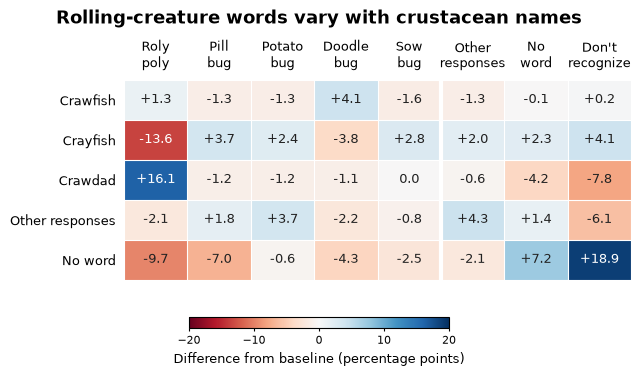

In [15]:
plot_question_association(
    pair_percentages, q74_baseline,
    "Rolling-creature words vary with crustacean names",
    "q66_q74_association"
)


In [16]:
group_tables = {}
for response in map_responses["Q065"]:
    group_data = plot_answers.loc[plot_answers["Q065"] == response]
    counts = pd.crosstab(group_data["Q066"], group_data["Q074"])
    counts = counts.reindex(index=q66_order, columns=q74_order, fill_value=0)
    row_counts = counts.sum(axis=1)
    percentages = 100 * counts.div(row_counts.where(row_counts > 0), axis=0)
    group_tables[response] = {
        "counts": counts, "row_counts": row_counts, "percentages": percentages,
    }
    assert counts.to_numpy().sum() == len(group_data)

shown_q65 = plot_answers["Q065"].isin(map_responses["Q065"])
excluded_q65_respondents = (~shown_q65).sum()


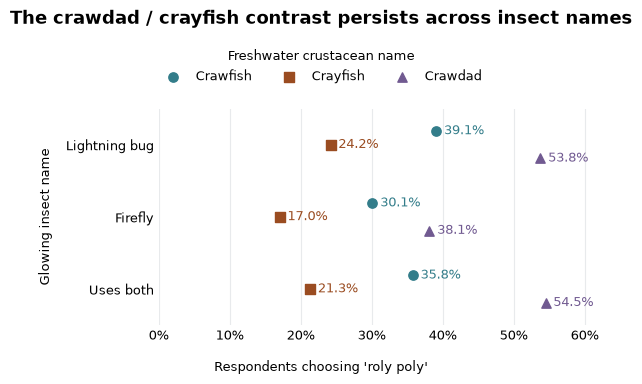

In [17]:
plot_three_question_association(
    group_tables, "The crawdad / crayfish contrast persists across insect names",
    "q65_q66_q74_association"
)


In [17]:
binary_answers, binary_respondents = preprocess_data(cleaned_data, one_hot=True)

assert (binary_answers.sum(axis=1) == len(question_columns)).all()

encoding_audit = pd.Series({
    "Raw respondents": len(raw_data),
    "Complete-case respondents": len(binary_answers),
    "Excluded respondents": len(raw_data) - len(binary_answers),
    "Excluded percent": 100 * (len(raw_data) - len(binary_answers)) / len(raw_data),
    "Survey questions": len(question_columns),
    "Binary answer columns": binary_answers.shape[1],
    "Constant binary columns": (binary_answers.nunique() == 1).sum(),
})
encoding_audit.round(2)


Raw respondents              47471.00
Complete-case respondents    40061.00
Excluded respondents          7410.00
Excluded percent                15.61
Survey questions                67.00
Binary answer columns          468.00
Constant binary columns          0.00
dtype: float64

In [18]:
region_states = {
    "Northeast": ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"],
    "Midwest": ["IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD"],
    "South": ["DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV", "AL", "KY", "MS", "TN",
              "AR", "LA", "OK", "TX"],
    "West": ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA"],
}
state_regions = {}
for region, states in region_states.items():
    for state in states:
        state_regions[state] = region
assert set(state_regions) == set(state_shapes["postal"])

respondent_regions = binary_respondents["state"].map(state_regions)
has_geography = respondent_regions.notna() & ~binary_respondents["location_conflict"]
# These exclusions affect geographic displays only, not model fitting.
geographic_regions = respondent_regions.loc[has_geography]
geographic_index = geographic_regions.index
geographic_audit = pd.Series({
    "Respondents fitted": len(binary_answers),
    "Geographic displays": len(geographic_regions),
    "Missing or invalid states": respondent_regions.isna().sum(),
    "Flagged location conflicts": binary_respondents["location_conflict"].sum(),
    "Omitted from geographic displays": (~has_geography).sum(),
})
display(geographic_audit)
display(geographic_regions.value_counts().reindex(region_states))


Respondents fitted                  40061
Geographic displays                 39673
Missing or invalid states             135
Flagged location conflicts            253
Omitted from geographic displays      388
dtype: int64

state
Northeast     9209
Midwest      13841
South         9312
West          7311
Name: count, dtype: int64

In [19]:
pca_components = 50
pca_models = {}
pca_scores = {}
pca_scaler = StandardScaler()
standardized_answers = pca_scaler.fit_transform(binary_answers)

pca_inputs = {"Centered": binary_answers, "Standardized": standardized_answers}
pca_rows = []
for name, data in pca_inputs.items():
    model = make_projection("PCA", n_components=pca_components)
    scores = model.fit_transform(data)
    columns = ["PC" + str(component) for component in range(1, pca_components + 1)]
    pca_models[name] = model
    pca_scores[name] = pd.DataFrame(scores, index=binary_answers.index, columns=columns)
    pca_rows.append({
        "Preprocessing": name,
        "PC1 percent": 100 * model.explained_variance_ratio_[0],
        "First 2 percent": 100 * model.explained_variance_ratio_[:2].sum(),
        "First 3 percent": 100 * model.explained_variance_ratio_[:3].sum(),
        "First 50 percent": 100 * model.explained_variance_ratio_.sum(),
    })
pca_summary = pd.DataFrame(pca_rows)
pca_summary.round(2)


,Preprocessing,PC1 percent,First 2 percent,First 3 percent,First 50 percent
0,Centered,4.04,7.65,10.58,56.30
1,Standardized,1.93,3.59,5.04,29.86


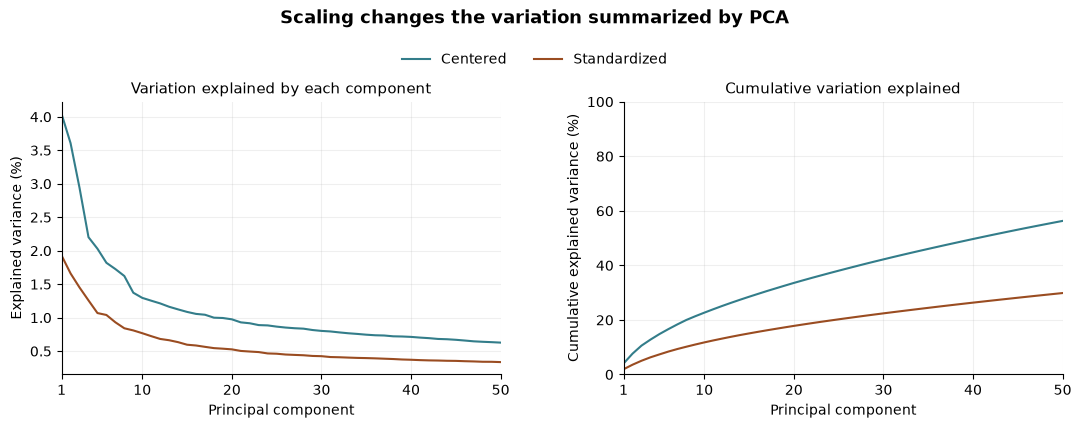

In [9]:
plot_pca_variance(pca_models, "Scaling changes the variation summarized by PCA",
                  "step3_pca_variance")


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


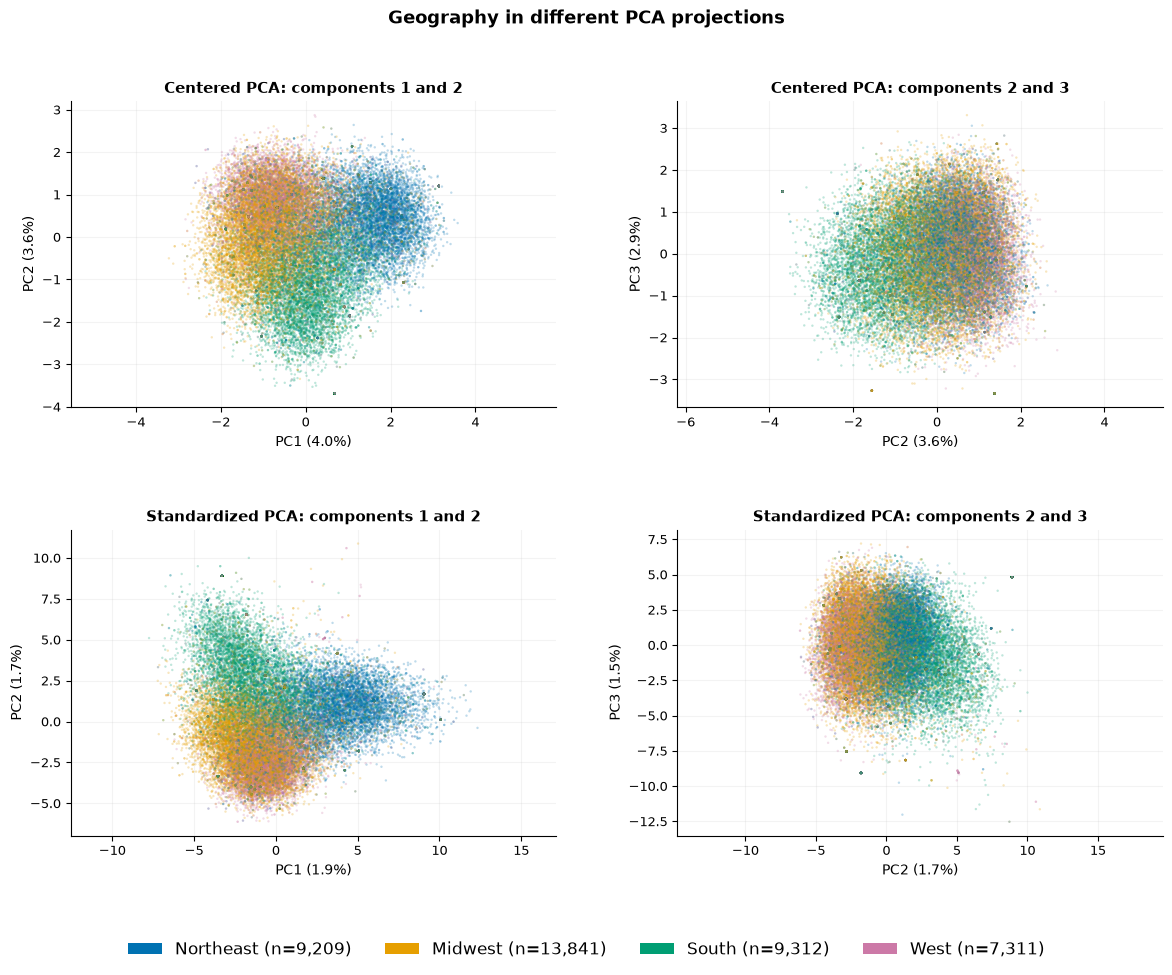

In [10]:
pca_views = {}
for name in pca_models:
    model = pca_models[name]
    for first, second in [(1, 2), (2, 3)]:
        pca_views[f"{name} PCA: components {first} and {second}"] = {
            "scores": pca_scores[name], "x": f"PC{first}", "y": f"PC{second}",
            "x_label": f"PC{first} ({100 * model.explained_variance_ratio_[first - 1]:.1f}%)",
            "y_label": f"PC{second} ({100 * model.explained_variance_ratio_[second - 1]:.1f}%)",
        }
plot_geographic_projections(pca_views, geographic_regions,
                            "Geography in different PCA projections", "step3_pca_geography")


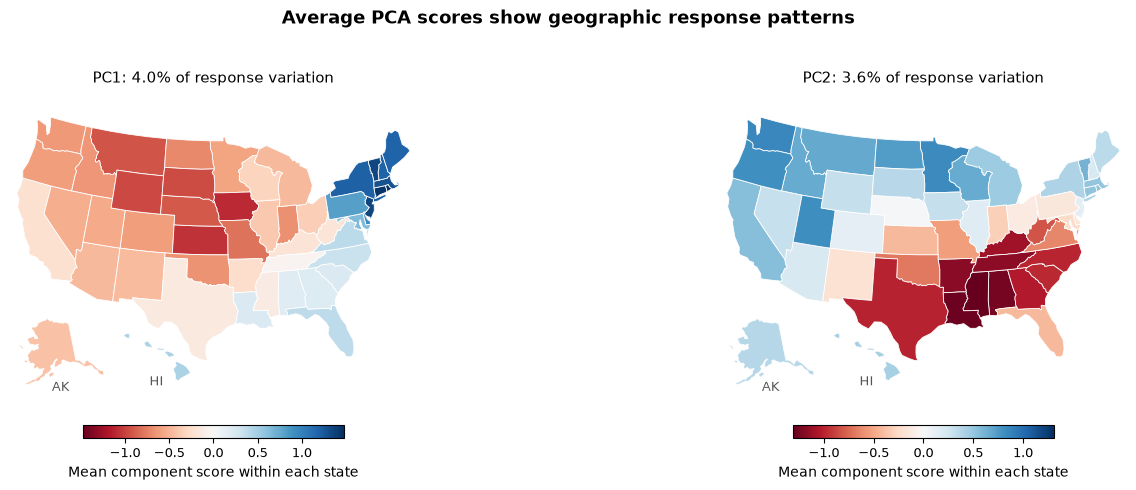

,state,PC1,PC2,respondents
0,AK,-0.43,0.37,74
1,AL,0.18,-1.25,343
2,AR,-0.27,-1.18,186
3,AZ,-0.47,0.21,311
4,CA,-0.23,0.56,3017
5,CO,-0.61,0.13,546
6,CT,1.44,0.53,890
7,DC,0.66,-0.08,140
8,DE,0.93,-0.18,84
9,FL,0.39,-0.42,1040


In [20]:
geographic_scores = pca_scores["Centered"].loc[geographic_index, ["PC1", "PC2"]]
geographic_scores = geographic_scores.join(binary_respondents.loc[geographic_index, ["state"]])
state_score_summary = geographic_scores.groupby("state", observed=True)[["PC1", "PC2"]].mean()
state_score_summary["respondents"] = geographic_scores.groupby("state", observed=True).size()
state_score_summary = state_score_summary.reset_index()
plot_component_maps(state_score_summary, state_shapes, ["PC1", "PC2"],
                    pca_models["Centered"].explained_variance_ratio_[:2],
                    "Average PCA scores show geographic response patterns", "step3_pca_score_maps",
                    min_respondents=30)
with pd.option_context("display.max_rows", None):
    display(state_score_summary.round(2))


In [12]:
tsne_models = {}
tsne_scores = {}
tsne_seed = 215
perplexity = 30
model = make_projection("t-SNE", perplexity=perplexity, random_state=tsne_seed)
scores = model.fit_transform(pca_scores["Centered"])
tsne_models[perplexity] = model
tsne_scores[perplexity] = pd.DataFrame(scores, index=binary_answers.index, columns=["Axis1", "Axis2"])


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 40061 samples in 0.011s...


[t-SNE] Computed neighbors for 40061 samples in 3.245s...
[t-SNE] Computed conditional probabilities for sample 1000 / 40061
[t-SNE] Computed conditional probabilities for sample 2000 / 40061
[t-SNE] Computed conditional probabilities for sample 3000 / 40061
[t-SNE] Computed conditional probabilities for sample 4000 / 40061
[t-SNE] Computed conditional probabilities for sample 5000 / 40061
[t-SNE] Computed conditional probabilities for sample 6000 / 40061
[t-SNE] Computed conditional probabilities for sample 7000 / 40061
[t-SNE] Computed conditional probabilities for sample 8000 / 40061
[t-SNE] Computed conditional probabilities for sample 9000 / 40061


[t-SNE] Computed conditional probabilities for sample 10000 / 40061
[t-SNE] Computed conditional probabilities for sample 11000 / 40061
[t-SNE] Computed conditional probabilities for sample 12000 / 40061
[t-SNE] Computed conditional probabilities for sample 13000 / 40061
[t-SNE] Computed conditional probabilities for sample 14000 / 40061
[t-SNE] Computed conditional probabilities for sample 15000 / 40061
[t-SNE] Computed conditional probabilities for sample 16000 / 40061
[t-SNE] Computed conditional probabilities for sample 17000 / 40061
[t-SNE] Computed conditional probabilities for sample 18000 / 40061
[t-SNE] Computed conditional probabilities for sample 19000 / 40061
[t-SNE] Computed conditional probabilities for sample 20000 / 40061
[t-SNE] Computed conditional probabilities for sample 21000 / 40061
[t-SNE] Computed conditional probabilities for sample 22000 / 40061
[t-SNE] Computed conditional probabilities for sample 23000 / 40061
[t-SNE] Computed conditional probabilities for s

[t-SNE] Computed conditional probabilities for sample 36000 / 40061
[t-SNE] Computed conditional probabilities for sample 37000 / 40061
[t-SNE] Computed conditional probabilities for sample 38000 / 40061
[t-SNE] Computed conditional probabilities for sample 39000 / 40061
[t-SNE] Computed conditional probabilities for sample 40000 / 40061
[t-SNE] Computed conditional probabilities for sample 40061 / 40061
[t-SNE] Mean sigma: 0.000000


[t-SNE] KL divergence after 250 iterations with early exaggeration: 110.316284


[t-SNE] KL divergence after 1000 iterations: 3.731346


In [13]:
perplexity = 50
model = make_projection("t-SNE", perplexity=perplexity, random_state=tsne_seed)
scores = model.fit_transform(pca_scores["Centered"])
tsne_models[perplexity] = model
tsne_scores[perplexity] = pd.DataFrame(scores, index=binary_answers.index, columns=["Axis1", "Axis2"])


[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 40061 samples in 0.008s...


[t-SNE] Computed neighbors for 40061 samples in 3.529s...
[t-SNE] Computed conditional probabilities for sample 1000 / 40061
[t-SNE] Computed conditional probabilities for sample 2000 / 40061
[t-SNE] Computed conditional probabilities for sample 3000 / 40061


[t-SNE] Computed conditional probabilities for sample 4000 / 40061
[t-SNE] Computed conditional probabilities for sample 5000 / 40061
[t-SNE] Computed conditional probabilities for sample 6000 / 40061
[t-SNE] Computed conditional probabilities for sample 7000 / 40061
[t-SNE] Computed conditional probabilities for sample 8000 / 40061
[t-SNE] Computed conditional probabilities for sample 9000 / 40061
[t-SNE] Computed conditional probabilities for sample 10000 / 40061
[t-SNE] Computed conditional probabilities for sample 11000 / 40061
[t-SNE] Computed conditional probabilities for sample 12000 / 40061
[t-SNE] Computed conditional probabilities for sample 13000 / 40061
[t-SNE] Computed conditional probabilities for sample 14000 / 40061
[t-SNE] Computed conditional probabilities for sample 15000 / 40061


[t-SNE] Computed conditional probabilities for sample 16000 / 40061
[t-SNE] Computed conditional probabilities for sample 17000 / 40061
[t-SNE] Computed conditional probabilities for sample 18000 / 40061
[t-SNE] Computed conditional probabilities for sample 19000 / 40061
[t-SNE] Computed conditional probabilities for sample 20000 / 40061
[t-SNE] Computed conditional probabilities for sample 21000 / 40061
[t-SNE] Computed conditional probabilities for sample 22000 / 40061
[t-SNE] Computed conditional probabilities for sample 23000 / 40061
[t-SNE] Computed conditional probabilities for sample 24000 / 40061
[t-SNE] Computed conditional probabilities for sample 25000 / 40061
[t-SNE] Computed conditional probabilities for sample 26000 / 40061
[t-SNE] Computed conditional probabilities for sample 27000 / 40061
[t-SNE] Computed conditional probabilities for sample 28000 / 40061
[t-SNE] Computed conditional probabilities for sample 29000 / 40061
[t-SNE] Computed conditional probabilities for s

[t-SNE] Computed conditional probabilities for sample 34000 / 40061
[t-SNE] Computed conditional probabilities for sample 35000 / 40061
[t-SNE] Computed conditional probabilities for sample 36000 / 40061
[t-SNE] Computed conditional probabilities for sample 37000 / 40061
[t-SNE] Computed conditional probabilities for sample 38000 / 40061
[t-SNE] Computed conditional probabilities for sample 39000 / 40061
[t-SNE] Computed conditional probabilities for sample 40000 / 40061
[t-SNE] Computed conditional probabilities for sample 40061 / 40061
[t-SNE] Mean sigma: 0.000000


[t-SNE] KL divergence after 250 iterations with early exaggeration: 104.995819


[t-SNE] KL divergence after 1000 iterations: 3.651789


,Perplexity,Respondents,PCA input components,Random seed,KL objective
0,30,40061,50,215,3.731
1,50,40061,50,215,3.652


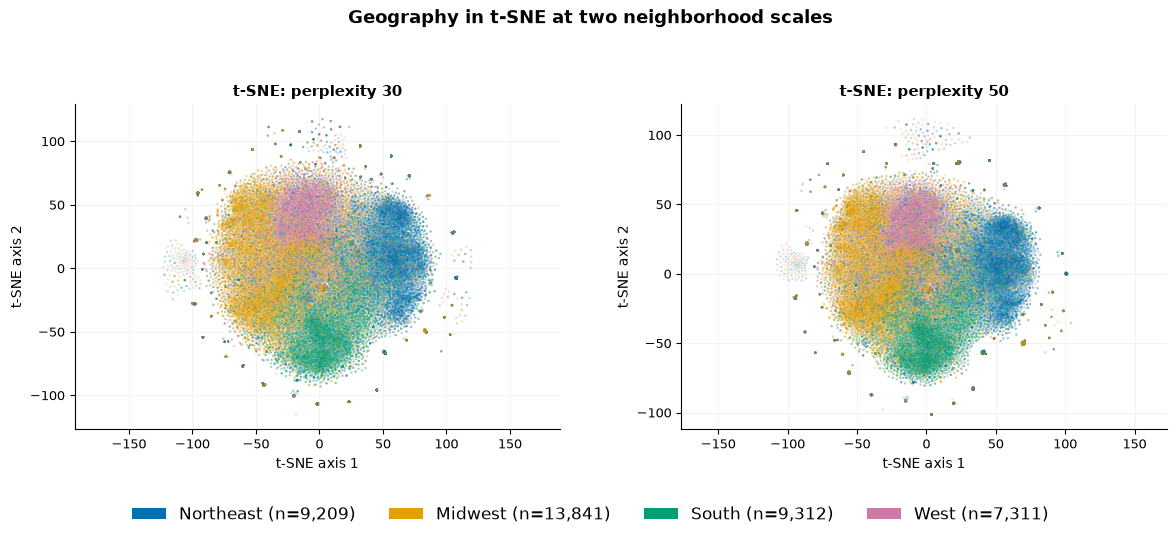

In [14]:
tsne_views = {}
tsne_rows = []
for perplexity, model in tsne_models.items():
    tsne_views[f"t-SNE: perplexity {perplexity}"] = {
        "scores": tsne_scores[perplexity], "x": "Axis1", "y": "Axis2",
        "x_label": "t-SNE axis 1", "y_label": "t-SNE axis 2",
    }
    tsne_rows.append({
        "Perplexity": perplexity, "Respondents": len(binary_answers),
        "PCA input components": pca_components, "Random seed": tsne_seed,
        "KL objective": model.kl_divergence_,
    })
tsne_summary = pd.DataFrame(tsne_rows)
display(tsne_summary.round(3))
plot_geographic_projections(tsne_views, geographic_regions,
                            "Geography in t-SNE at two neighborhood scales", "step3_tsne_geography")


In [21]:
loadings = pd.DataFrame(pca_models["Centered"].components_.T,
                        index=binary_answers.columns, columns=pca_scores["Centered"].columns)
loading_rows = []
for component in ["PC1", "PC2"]:
    for direction in ["Positive", "Negative"]:
        if direction == "Positive":
            shown = loadings[component].nlargest(5)
        else:
            shown = loadings[component].nsmallest(5)
        for feature, loading in shown.items():
            question, answer = feature.split("__", 1)
            loading_rows.append({
                "Component": component, "Direction": direction,
                "Question": question, "Answer": answer, "Loading": loading,
            })
loading_summary = pd.DataFrame(loading_rows)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(loading_summary.round(3))


,Component,Direction,Question,Answer,Loading
0,PC1,Positive,Q073,sneakers,0.260
1,PC1,Positive,Q105,soda,0.191
2,PC1,Positive,Q080,sunshower,0.179
3,PC1,Positive,Q056,unacceptable,0.161
4,PC1,Positive,Q103,water fountain,0.150
5,PC1,Negative,Q073,tennis shoes,-0.234
6,PC1,Negative,Q080,I have no term or expression for this,-0.179
7,PC1,Negative,Q105,pop,-0.178
8,PC1,Negative,Q106,tp'ing,-0.169
9,PC1,Negative,Q103,drinking fountain,-0.165


Both methods use **five clusters** to compare their partitions at the same resolution. Five is a working choice for this comparison, rather than an established number of dialect regions.

The K-means inertia curve provides context for the choice. The extended GMM BIC curve evaluates density fit: lower BIC can favor additional Gaussian components, including components concentrated on repeated answer patterns. We retain five components for the comparison and report the lowest BIC among the tested candidates separately. More components may improve the density fit without identifying more meaningful dialect groups.

The dashed lines mark the five clusters used in the comparison figures. The supporting BIC analysis is limited to candidate counts up to 100; it does not establish a global BIC minimum.

In [3]:
from sklearn.metrics import adjusted_rand_score, rand_score
from threadpoolctl import threadpool_limits
from models import make_clustering
from plots import (plot_cluster_selection, plot_cluster_projections,
                   plot_cluster_profiles,
                   plot_cluster_agreement)

clustering_input = pca_scores["Centered"]
clustering_seed = 215
min_cluster_state_respondents = 30
comparison_k = 5
cluster_ranges = {
    "K-means": range(1, 9),
    "GMM": list(range(1, 65)) + [80, 96, 100],
}

clustering_audit = pd.Series({
    "Raw respondents": len(raw_data),
    "Respondents fitted": len(clustering_input),
    "Excluded for missing answers": len(raw_data) - len(clustering_input),
    "Survey questions": len(question_columns),
    "Principal components fitted": clustering_input.shape[1],
    "Response variation retained (%)": 100 * pca_models["Centered"].explained_variance_ratio_.sum(),
    "Clusters used for both methods": comparison_k,
    "GMM candidate counts tested": len(cluster_ranges["GMM"]),
    "Random seed": clustering_seed,
})
clustering_audit.round(2)


Raw respondents                    47471.0
Respondents fitted                 40061.0
Excluded for missing answers        7410.0
Survey questions                      67.0
Principal components fitted           50.0
Response variation retained (%)       56.3
Clusters used for both methods         5.0
GMM candidate counts tested           67.0
Random seed                          215.0
dtype: float64

In [4]:
clustering_models = {"K-means": {}, "GMM": {}}
clustering_rows = []
with threadpool_limits(limits=4):
    for name in clustering_models:
        for n_clusters in cluster_ranges[name]:
            model = make_clustering(name, n_clusters=n_clusters, random_state=clustering_seed)
            model.fit(clustering_input)
            clustering_models[name][n_clusters] = model
            labels = model.predict(clustering_input)
            counts = pd.Series(labels).value_counts()
            converged = model.n_iter_ < model.max_iter if name == "K-means" else model.converged_
            clustering_rows.append({
                "Method": name, "K": n_clusters,
                "Inertia": model.inertia_ if name == "K-means" else np.nan,
                "BIC": model.bic(clustering_input) if name == "GMM" else np.nan,
                "Converged": converged, "Iterations": model.n_iter_,
                "Occupied clusters": len(counts),
                "Smallest cluster (%)": 100 * counts.min() / len(labels),
            })
            print(f"{name}, K={n_clusters}: completed ({model.n_iter_} iterations)")

clustering_summary = pd.DataFrame(clustering_rows)
display(clustering_summary.round(3))


K-means, K=1: completed (2 iterations)
K-means, K=2: completed (38 iterations)
K-means, K=3: completed (12 iterations)
K-means, K=4: completed (29 iterations)
K-means, K=5: completed (23 iterations)
K-means, K=6: completed (55 iterations)
K-means, K=7: completed (58 iterations)
K-means, K=8: completed (112 iterations)
GMM, K=1: completed (2 iterations)
GMM, K=2: completed (11 iterations)
GMM, K=3: completed (33 iterations)
GMM, K=4: completed (11 iterations)
GMM, K=5: completed (24 iterations)
GMM, K=6: completed (17 iterations)
GMM, K=7: completed (30 iterations)
GMM, K=8: completed (26 iterations)
GMM, K=9: completed (44 iterations)
GMM, K=10: completed (35 iterations)
GMM, K=11: completed (42 iterations)
GMM, K=12: completed (31 iterations)
GMM, K=13: completed (49 iterations)
GMM, K=14: completed (35 iterations)
GMM, K=15: completed (48 iterations)
GMM, K=16: completed (24 iterations)
GMM, K=17: completed (25 iterations)
GMM, K=18: completed (37 iterations)
GMM, K=19: completed (43

,Method,K,Inertia,BIC,Converged,Iterations,Occupied clusters,Smallest cluster (%)
0,K-means,1,814610.751,NaN,True,2,1,100.000
1,K-means,2,772812.178,NaN,True,38,2,44.999
2,K-means,3,740400.330,NaN,True,12,3,28.427
3,K-means,4,723434.669,NaN,True,29,4,20.546
4,K-means,5,705527.784,NaN,True,23,5,1.590
...,...,...,...,...,...,...,...,...
70,GMM,63,NaN,1449218.021,True,18,63,0.132
71,GMM,64,NaN,1349817.437,True,34,64,0.102
72,GMM,80,NaN,1244475.654,True,45,80,0.070
73,GMM,96,NaN,1096173.217,True,48,96,0.052


,Method,Clusters for comparison,Selection rationale
0,K-means,5,Shared working resolution
1,GMM,5,Shared working resolution


GMM K with lowest tested BIC              96
GMM K used for comparison                  5
Highest GMM K tested                     100
BIC minimum at largest tested K        False
Lowest tested BIC                  1096173.2
BIC at comparison K                3164478.4
dtype: object

,K-means,GMM
Cluster,,
1,8778,4863
2,11053,24373
3,9790,1100
4,637,635
5,9803,9090


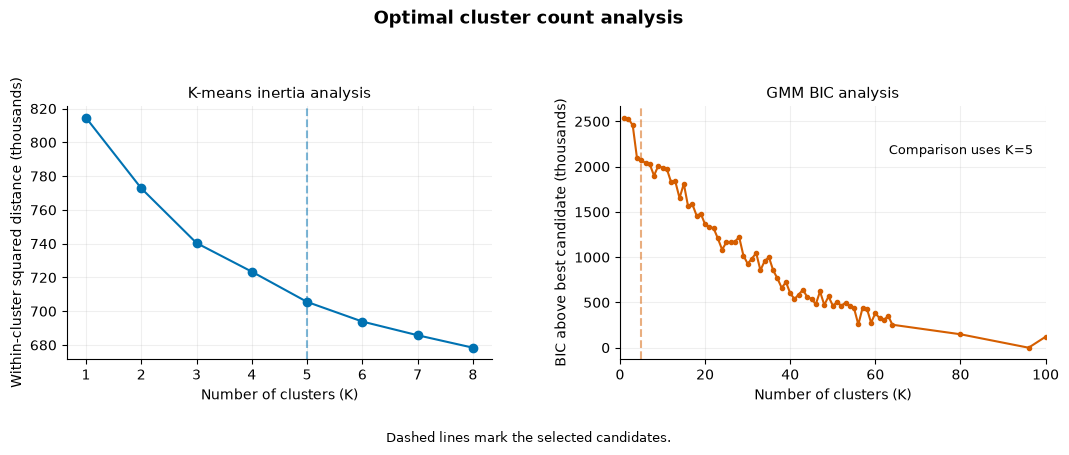

In [5]:
selected_k = {name: comparison_k for name in clustering_models}
selected_models = {name: clustering_models[name][k] for name, k in selected_k.items()}
cluster_labels = pd.DataFrame({name: model.predict(clustering_input) + 1
                              for name, model in selected_models.items()},
                             index=clustering_input.index)
selection_summary = pd.DataFrame({
    "Method": list(selected_k), "Clusters for comparison": list(selected_k.values()),
    "Selection rationale": ["Shared working resolution", "Shared working resolution"],
})

gmm_candidates = clustering_summary.loc[
    (clustering_summary["Method"] == "GMM") & clustering_summary["Converged"]
].set_index("K")
best_gmm_k = int(gmm_candidates["BIC"].idxmin())
bic_summary = pd.Series({
    "GMM K with lowest tested BIC": best_gmm_k,
    "GMM K used for comparison": comparison_k,
    "Highest GMM K tested": max(cluster_ranges["GMM"]),
    "BIC minimum at largest tested K": best_gmm_k == max(cluster_ranges["GMM"]),
    "Lowest tested BIC": round(gmm_candidates["BIC"].min(), 1),
    "BIC at comparison K": round(gmm_candidates.loc[comparison_k, "BIC"], 1),
})

display(selection_summary)
display(bic_summary)
display(cluster_labels.apply(pd.Series.value_counts).fillna(0).astype(int).rename_axis("Cluster"))
plot_cluster_selection(clustering_summary, selected_k,
                       "Optimal cluster count analysis", "step4_cluster_selection")


In [7]:
answer_patterns = raw_data.loc[clustering_input.index, question_columns]
pattern_counts = answer_patterns.value_counts()
display(pd.Series({
    "Respondents fitted": len(answer_patterns),
    "Distinct full-answer patterns": len(pattern_counts),
    "Largest repeated pattern": pattern_counts.iloc[0],
}))
cluster_pattern_rows = []
for name in cluster_labels:
    for cluster in sorted(cluster_labels[name].unique()):
        selected = answer_patterns.loc[cluster_labels[name] == cluster]
        frequencies = selected.value_counts()
        at_floor = np.nan
        if name == "GMM":
            model = selected_models[name]
            at_floor = (model.covariances_[cluster - 1] <= 1.01 * model.reg_covar).sum()
        cluster_pattern_rows.append({
            "Method": name, "Cluster": cluster, "Respondents": len(selected),
            "Distinct answer patterns": len(frequencies),
            "Largest pattern (%)": 100 * frequencies.iloc[0] / len(selected),
            "PC variances at regularization floor": at_floor,
        })
cluster_pattern_audit = pd.DataFrame(cluster_pattern_rows)
display(cluster_pattern_audit.round(2))


Respondents fitted               40061
Distinct full-answer patterns    30400
Largest repeated pattern           635
dtype: int64

,Method,Cluster,Respondents,Distinct answer patterns,Largest pattern (%),PC variances at regularization floor
0,K-means,1,8778,6778,2.06,NaN
1,K-means,2,11053,8482,1.53,NaN
2,K-means,3,9790,7364,2.31,NaN
3,K-means,4,637,3,99.69,NaN
4,K-means,5,9803,7773,1.50,NaN
5,GMM,1,4863,3353,3.72,0.0
6,GMM,2,24373,19847,0.39,0.0
7,GMM,3,1100,14,20.55,0.0
8,GMM,4,635,1,100.00,50.0
9,GMM,5,9090,7185,1.62,0.0


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


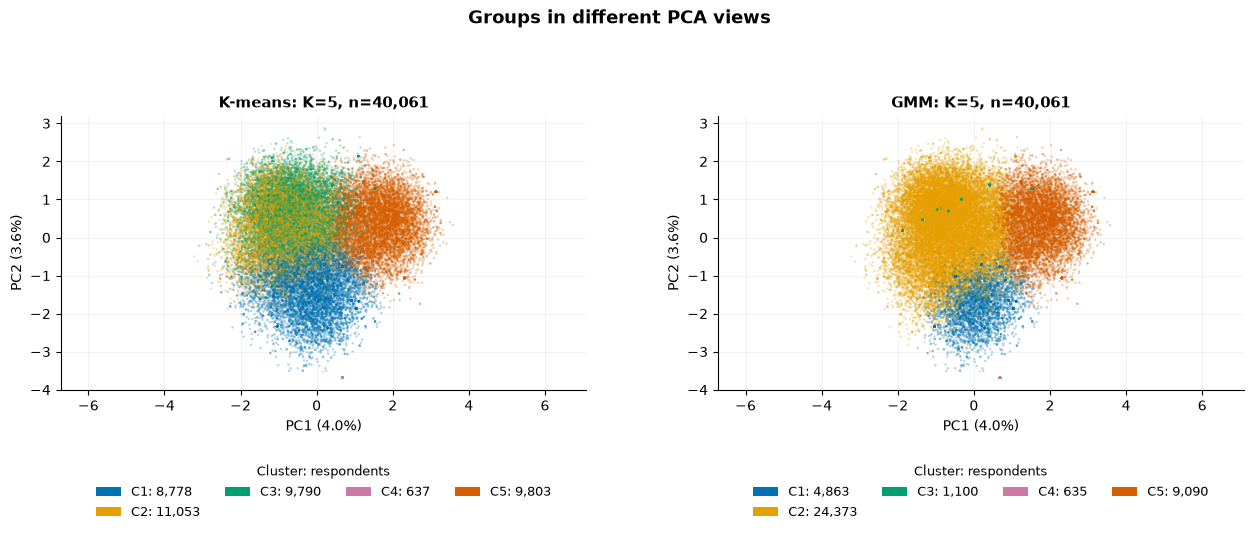

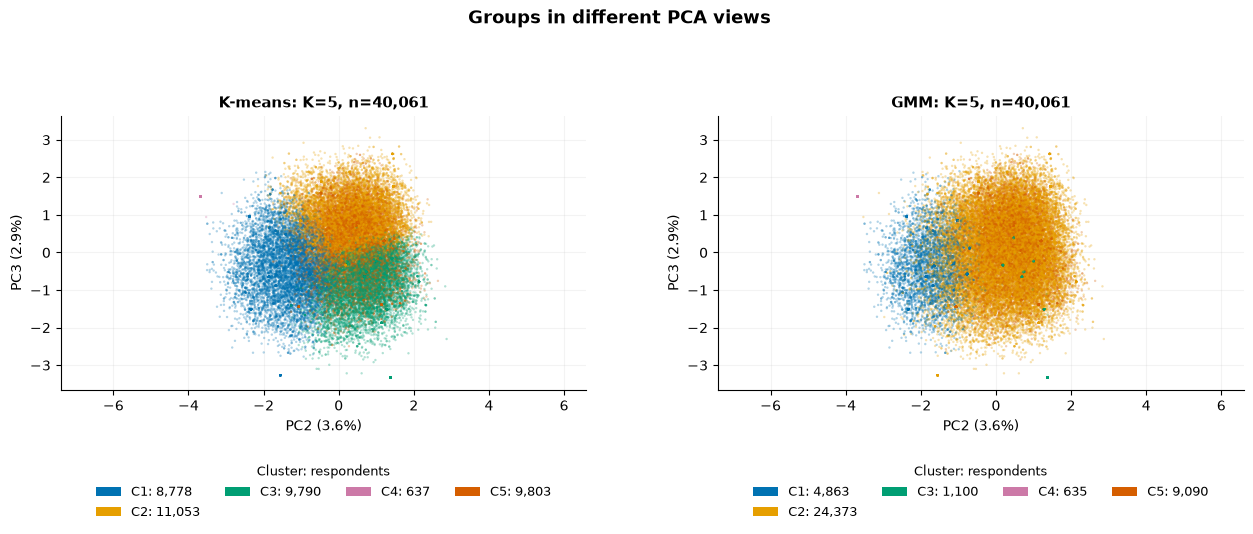

In [6]:
for components in [(1, 2), (2, 3)]:
    plot_cluster_projections(clustering_input, cluster_labels,
                             pca_models["Centered"].explained_variance_ratio_, components,
                             "Groups in different PCA views",
                             f"step4_clusters_pc{components[0]}_pc{components[1]}")


Fitted respondents                      40061
Geographic respondents                  39673
Omitted from geography                    388
Minimum respondents per mapped state       30
States below minimum                        0
dtype: int64

1     2     3    4     5
Method  Region                                
K-means Northeast   8.7   9.2  11.2  1.6  69.3
        Midwest    16.9  42.3  31.9  1.1   7.8
        South      54.4  14.0  12.5  2.7  16.3
        West        6.8  40.1  42.0  1.1   9.9
GMM     Northeast   4.8  24.4   2.4  1.6  66.7
        Midwest     5.3  84.2   2.8  1.1   6.5
        South      36.3  43.2   3.2  2.6  14.7
        West        3.7  84.7   2.5  1.1   8.0

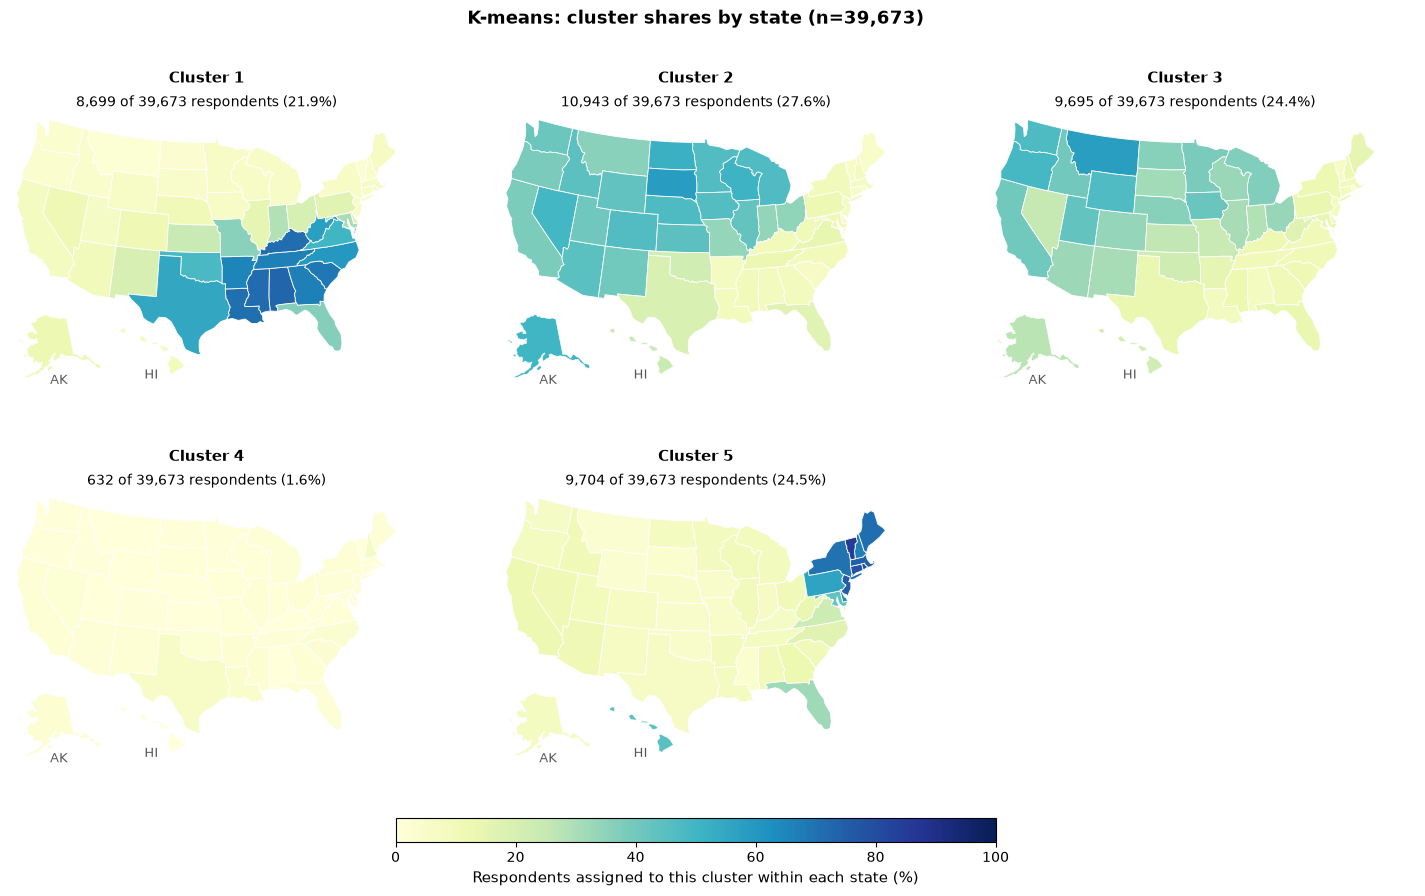

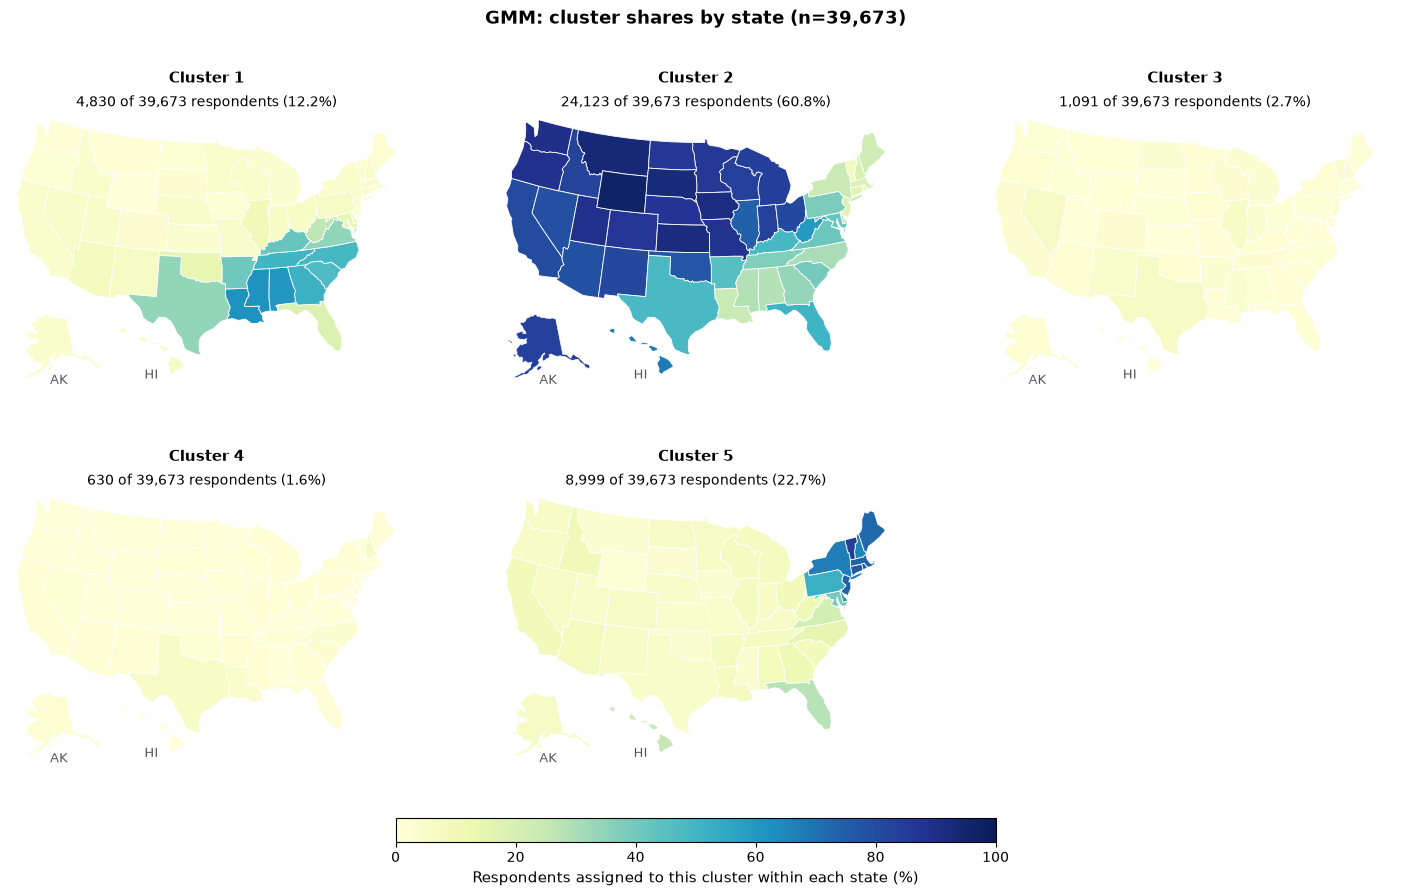

In [10]:
clustering_geography = cluster_labels.loc[geographic_index].join(
    binary_respondents.loc[geographic_index, ["state"]]
)
cluster_state_counts = clustering_geography.groupby("state", observed=True).size()
cluster_map_rows = []
region_cluster_tables = {}
for name in cluster_labels:
    clusters = range(1, selected_k[name] + 1)
    state_counts = pd.crosstab(clustering_geography["state"], clustering_geography[name])
    state_counts = state_counts.reindex(columns=clusters, fill_value=0)
    for cluster in clusters:
        for state, total in cluster_state_counts.items():
            count = state_counts.loc[state, cluster]
            cluster_map_rows.append({
                "question": name, "answer": f"Cluster {cluster}", "state": state,
                "responses": count, "respondents": total, "percent": 100 * count / total,
            })
    region_counts = pd.crosstab(geographic_regions, cluster_labels.loc[geographic_index, name])
    region_counts = region_counts.reindex(index=region_states, columns=clusters, fill_value=0)
    region_cluster_tables[name] = 100 * region_counts.div(region_counts.sum(axis=1), axis=0)

cluster_state_summary = pd.DataFrame(cluster_map_rows)
display(pd.Series({
    "Fitted respondents": len(cluster_labels),
    "Geographic respondents": len(clustering_geography),
    "Omitted from geography": len(cluster_labels) - len(clustering_geography),
    "Minimum respondents per mapped state": min_cluster_state_respondents,
    "States below minimum": (cluster_state_counts < min_cluster_state_respondents).sum(),
}))
display(pd.concat(region_cluster_tables, names=["Method", "Region"]).round(1))
for name in cluster_labels:
    plot_response_maps(cluster_state_summary, state_shapes, name,
                       [f"Cluster {cluster}" for cluster in range(1, selected_k[name] + 1)],
                       f"{name}: cluster shares by state (n={len(clustering_geography):,})",
                       "step4_" + ("kmeans" if name == "K-means" else "gmm") + "_state_maps",
                       min_respondents=min_cluster_state_respondents,
                       colorbar_label="Respondents assigned to this cluster within each state (%)")


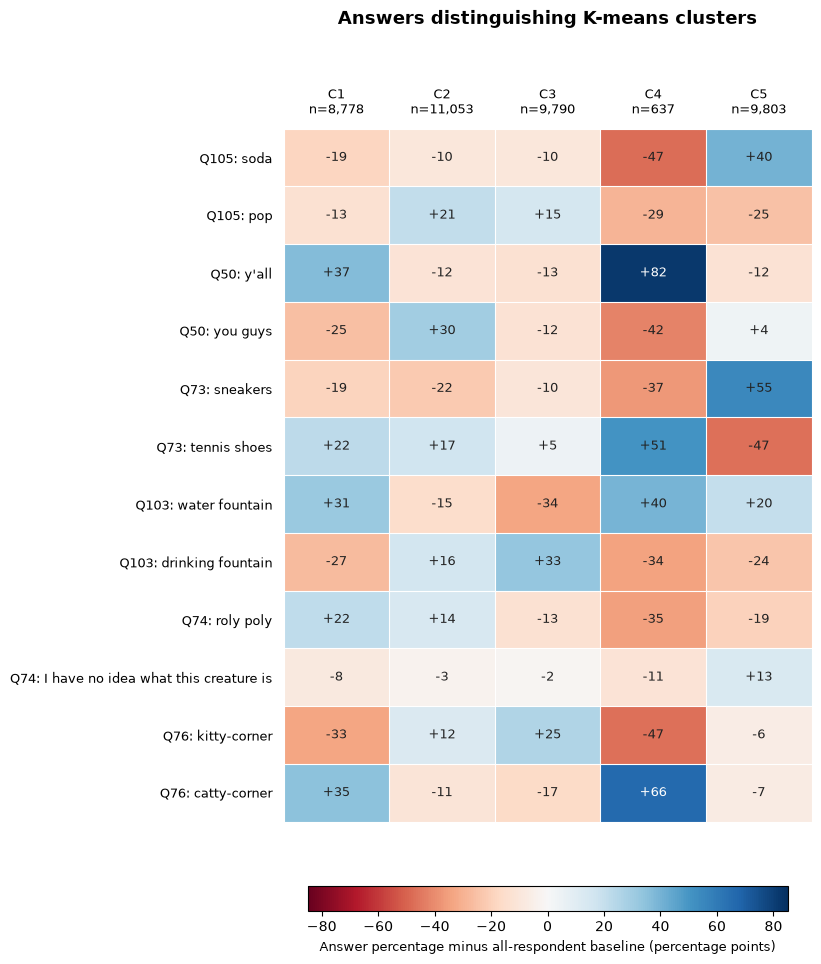

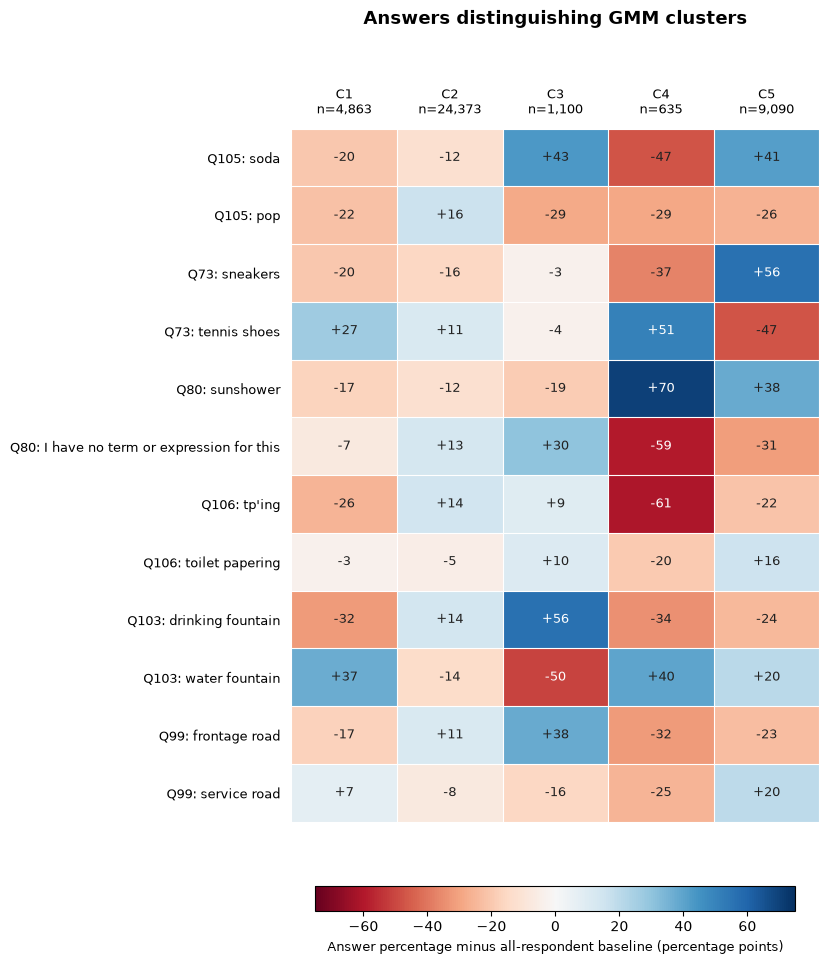

,Method,Question,Weighted distribution difference (TV %),Question text
0,K-means,Q105,29.46,What is your generic term for a sweetened carbonated beverage?
1,K-means,Q050,28.17,What word(s) do you use to address a group of two or more people?
2,K-means,Q073,28.16,"What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?"
3,K-means,Q103,26.09,What do you call the thing from which you might drink water in a school?
4,K-means,Q074,23.04,What do you call the little gray creature (that looks like an insect but is actually a crustacean) that rolls up into a ball when you touch it?
5,K-means,Q076,22.96,What term do you use to refer to something that is across both streets from you at an intersection (or diagonally across from you in general)?
6,K-means,Q099,22.64,Which of these terms do you prefer for the small road parallel to the highway?
7,K-means,Q106,21.85,What do you call the act of covering a house or area in front of a house with toilet paper?
8,K-means,Q080,21.54,What do you call it when rain falls while the sun is shining?
9,K-means,Q086,18.68,Do you use the word cruller?


In [7]:
baseline = 100 * binary_answers.mean()
question_text = question_data["quest.use"].set_index("qnum")["quest"]
question_features = {}
for question in question_columns:
    question_features[question] = [feature for feature in binary_answers
                                   if feature.startswith(question + "__")]

cluster_profiles = {}
question_tables = []
for name in cluster_labels:
    profiles = 100 * binary_answers.groupby(cluster_labels[name]).mean()
    cluster_profiles[name] = profiles
    counts = cluster_labels[name].value_counts().reindex(profiles.index)
    weights = counts / len(cluster_labels)
    differences = profiles.sub(baseline, axis=1)
    answer_separation = differences.abs().mul(weights, axis=0).sum(axis=0)

    question_rows = []
    for question, features in question_features.items():
        question_rows.append({
            "Method": name, "Question": question,
            "Weighted distribution difference (TV %)": 0.5 * answer_separation.loc[features].sum(),
            "Question text": question_text.loc[int(question[1:])],
        })
    ranked = pd.DataFrame(question_rows).sort_values("Weighted distribution difference (TV %)",
                                                   ascending=False)
    question_tables.append(ranked)
    shown_features = []
    for question in ranked.head(6)["Question"]:
        shown_features.extend(answer_separation.loc[question_features[question]].nlargest(2).index)
    plot_cluster_profiles(differences[shown_features].T, counts,
                          f"Answers distinguishing {name} clusters",
                          "step4_" + ("kmeans" if name == "K-means" else "gmm") + "_answer_profiles")

question_separation = pd.concat(question_tables, ignore_index=True)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(question_separation.groupby("Method", sort=False).head(10).round(2))


Respondents compared    40061.000
K-means K                   5.000
GMM K                       5.000
Rand index                  0.701
Adjusted Rand index         0.362
dtype: float64

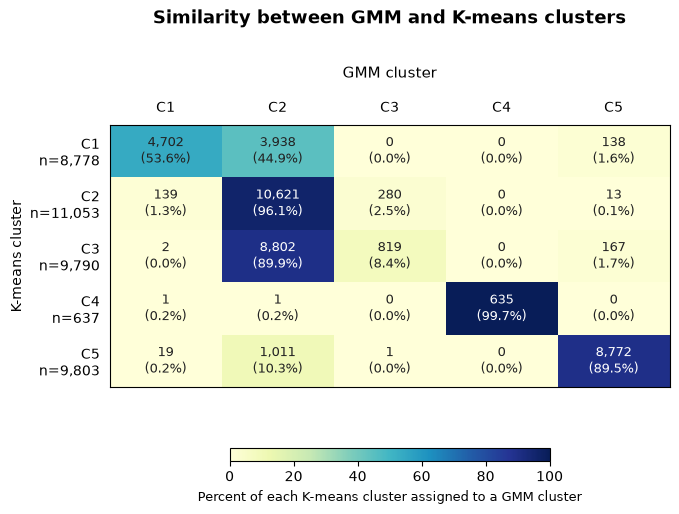

In [12]:
cluster_agreement = pd.crosstab(cluster_labels["K-means"], cluster_labels["GMM"])
agreement_summary = pd.Series({
    "Respondents compared": len(cluster_labels),
    "K-means K": selected_k["K-means"],
    "GMM K": selected_k["GMM"],
    "Rand index": rand_score(cluster_labels["K-means"], cluster_labels["GMM"]),
    "Adjusted Rand index": adjusted_rand_score(cluster_labels["K-means"], cluster_labels["GMM"]),
})
display(agreement_summary.round(3))
plot_cluster_agreement(cluster_agreement, "Similarity between GMM and K-means clusters",
                       "step4_cluster_agreement")


Step 5 checks the five-cluster K-means result using 20 different initialization seeds and 20 bootstrap samples. Each bootstrap refits centered PCA with 50 components; the seed check keeps the Step 3 PCA fixed. K and the remaining K-means settings stay unchanged.

Compare assignments on the same complete-case cohort, with a separate out-of-bag comparison for respondents omitted from each bootstrap fit. This assesses stability relative to Step 4, not predictive accuracy or the existence of true dialect regions.


In [7]:
from models import fit_resampled_clustering, align_cluster_labels
from plots import plot_cluster_stability

stability_method = "K-means"
stability_k = selected_k[stability_method]
stability_repeats = 20
stability_seed = 5215

assert binary_answers.index.equals(clustering_input.index)
reference_labels = cluster_labels[stability_method]
stability_clusters = range(1, stability_k + 1)
reference_counts = reference_labels.value_counts().sort_index()
reference_profiles = 100 * binary_answers.groupby(reference_labels).mean()
reference_region_counts = pd.crosstab(geographic_regions,
                                      reference_labels.loc[geographic_index])
reference_region_counts = reference_region_counts.reindex(index=region_states,
                                                           columns=stability_clusters, fill_value=0)
reference_region_shares = 100 * reference_region_counts.div(
    reference_region_counts.sum(axis=1), axis=0
)

stability_audit = pd.Series({
    "Method": stability_method, "Reference clusters": stability_k,
    "Respondents compared": len(reference_labels),
    "Binary features": binary_answers.shape[1],
    "PCA components": clustering_input.shape[1],
    "Repetitions per check": stability_repeats,
    "K-means initializations per fit": selected_models[stability_method].n_init,
    "Bootstrap draws per fit": len(reference_labels),
    "Refit PCA in bootstrap": True,
    "Bootstrap sampling seed": stability_seed,
})
display(stability_audit)


Method                             K-means
Reference clusters                       5
Respondents compared                 40061
Binary features                        468
PCA components                          50
Repetitions per check                   20
K-means initializations per fit         10
Bootstrap draws per fit              40061
Refit PCA in bootstrap                True
Bootstrap sampling seed               5215
dtype: object

In [8]:
stability_rows = []
stability_cluster_rows = []
stability_labels = {"Different starts": {}, "Bootstrap": {}}
stability_rng = np.random.default_rng(stability_seed)
all_positions = np.arange(len(reference_labels))

with threadpool_limits(limits=4):
    for experiment in stability_labels:
        for run in range(1, stability_repeats + 1):
            if experiment == "Different starts":
                positions = all_positions
                fit_seed = clustering_seed + run
                refit_pca = False
            else:
                positions = stability_rng.integers(0, len(all_positions), len(all_positions))
                fit_seed = clustering_seed
                refit_pca = True

            fitted, labels, projection = fit_resampled_clustering(
                stability_method, binary_answers, clustering_input, positions,
                n_clusters=stability_k, random_state=fit_seed, refit_pca=refit_pca
            )
            aligned, jaccard = align_cluster_labels(reference_labels, labels, stability_k)
            aligned = pd.Series(aligned, index=reference_labels.index)
            stability_labels[experiment][run] = aligned

            # Respondents never drawn into the bootstrap form the out-of-bag group.
            unique_positions = np.unique(positions)
            omitted = np.ones(len(all_positions), dtype=bool)
            omitted[unique_positions] = False
            out_of_bag_ari = np.nan
            if experiment == "Bootstrap":
                out_of_bag_ari = adjusted_rand_score(reference_labels.to_numpy()[omitted],
                                                    labels[omitted])
            retained = (projection if refit_pca else pca_models["Centered"]).explained_variance_ratio_.sum()
            stability_rows.append({
                "Experiment": experiment, "Run": run, "Model seed": fit_seed,
                "Refit PCA": refit_pca, "Training draws": len(positions),
                "Distinct training respondents": len(unique_positions),
                "Out-of-bag respondents": int(omitted.sum()),
                "Iterations": fitted.n_iter_,
                "Reached iteration limit": fitted.n_iter_ >= fitted.max_iter,
                "Occupied training clusters": len(np.unique(fitted.labels_)),
                "Retained response variation (%)": 100 * retained,
                "All-respondent ARI": adjusted_rand_score(reference_labels, labels),
                "Out-of-bag ARI": out_of_bag_ari,
            })

            counts = aligned.value_counts().reindex(stability_clusters, fill_value=0)
            profiles = 100 * binary_answers.groupby(aligned).mean().reindex(stability_clusters)
            # The factor 0.5 avoids counting a move between answers twice.
            profile_change = 0.5 * profiles.sub(reference_profiles).abs().sum(axis=1, min_count=1)
            profile_change = profile_change / len(question_columns)
            region_counts = pd.crosstab(geographic_regions, aligned.loc[geographic_index])
            region_counts = region_counts.reindex(index=region_states, columns=stability_clusters,
                                                   fill_value=0)
            region_shares = 100 * region_counts.div(region_counts.sum(axis=1), axis=0)
            region_change = region_shares.sub(reference_region_shares).abs().mean(axis=0)
            for cluster in stability_clusters:
                stability_cluster_rows.append({
                    "Experiment": experiment, "Run": run, "Cluster": cluster,
                    "Reference respondents": reference_counts.loc[cluster],
                    "Jaccard": jaccard[cluster - 1],
                    "Respondents assigned": counts.loc[cluster],
                    "Cluster share change (pp)": 100 * abs(counts.loc[cluster] - reference_counts.loc[cluster]) / len(reference_labels),
                    "Mean question TV (%)": profile_change.loc[cluster],
                    "Mean regional share change (pp)": region_change.loc[cluster],
                })
            print(f"{experiment}, run {run}/{stability_repeats}: "
                  f"ARI={stability_rows[-1]['All-respondent ARI']:.3f}, "
                  f"out-of-bag n={omitted.sum():,}")

stability_runs = pd.DataFrame(stability_rows)
cluster_stability_runs = pd.DataFrame(stability_cluster_rows)
stability_labels = {name: pd.DataFrame(runs) for name, runs in stability_labels.items()}


Different starts, run 1/20: ARI=0.922, out-of-bag n=0


Different starts, run 2/20: ARI=0.900, out-of-bag n=0


Different starts, run 3/20: ARI=0.809, out-of-bag n=0


Different starts, run 4/20: ARI=0.909, out-of-bag n=0


Different starts, run 5/20: ARI=0.885, out-of-bag n=0


...

Bootstrap, run 16/20: ARI=0.566, out-of-bag n=14,693


Bootstrap, run 17/20: ARI=0.875, out-of-bag n=14,835


Bootstrap, run 18/20: ARI=0.869, out-of-bag n=14,823


Bootstrap, run 19/20: ARI=0.864, out-of-bag n=14,641


Bootstrap, run 20/20: ARI=0.470, out-of-bag n=14,671


In [9]:
stability_summary = stability_runs.groupby("Experiment", sort=False).agg({
    "Run": "count",
    "All-respondent ARI": ["median", "min", "max"],
    "Out-of-bag ARI": ["median", "min", "max"],
    "Reached iteration limit": "sum",
    "Occupied training clusters": "min",
})
cluster_stability_summary = cluster_stability_runs.groupby(
    ["Experiment", "Cluster"], sort=False
).agg({
    "Reference respondents": "first",
    "Jaccard": ["median", "min", "max"],
})
interpretation_stability_summary = cluster_stability_runs.groupby(
    ["Experiment", "Cluster"], sort=False
).agg({
    "Cluster share change (pp)": ["median", "max"],
    "Mean question TV (%)": ["median", "max"],
    "Mean regional share change (pp)": ["median", "max"],
})
display(stability_summary.round(4))
display(cluster_stability_summary.round(4))
display(interpretation_stability_summary.round(3))


Run All-respondent ARI                 Out-of-bag ARI  \
                 count             median     min     max         median   
Experiment                                                                 
Different starts    20             0.8847  0.7301  0.9222            NaN   
Bootstrap           20             0.8847  0.4698  0.9523         0.8883   

                                 Reached iteration limit  \
                     min     max                     sum   
Experiment                                                 
Different starts     NaN     NaN                       0   
Bootstrap         0.4738  0.9548                       0   

                 Occupied training clusters  
                                        min  
Experiment                                   
Different starts                          5  
Bootstrap                                 5

Reference respondents Jaccard                
                                         first  median     min     max
Experiment       Cluster                                              
Different starts 1                        8778  0.9523  0.7954  0.9624
                 2                       11053  0.8888  0.7321  0.9329
                 3                        9790  0.8711  0.7076  0.9347
                 4                         637  1.0000  1.0000  1.0000
                 5                        9803  0.9612  0.9498  0.9855
Bootstrap        1                        8778  0.9469  0.6074  0.9766
                 2                       11053  0.8889  0.4592  0.9701
                 3                        9790  0.8783  0.2996  0.9400
                 4                         637  1.0000  0.0000  1.0000
                 5                        9803  0.9603  0.8434  0.9783

Cluster share change (pp)          \
                                            median     max   
Experiment       Cluster                                     
Different starts 1                           0.382   3.083   
                 2                           1.628   2.529   
                 3                           1.432   4.853   
                 4                           0.000   0.000   
                 5                           0.441   0.617   
Bootstrap        1                           0.459   5.177   
                 2                           1.118   5.447   
                 3                           0.652   5.918   
                 4                           0.000  16.655   
                 5                           0.402   2.149   

                         Mean question TV (%)          \
                                       median     max   
Experiment       Cluster                                
Different starts 1                      0.511   3.127   
                 2                      1.454   3.321   
                 3                      2.000   3.931   
                 4                      0.000   0.000   
                 5                      0.845   0.898   
Bootstrap        1                      0.499   7.185   
                 2                      1.485   7.793   
                 3                      1.907  11.573   
                 4                      0.000  53.348   
                 5                      0.822   2.491   

                         Mean regional share change (pp)          
                                                  median     max  
Experiment       Cluster                                          
Different starts 1                                 0.334   2.756  
                 2                                 1.680   2.904  
                 3                                 1.725   5.122  
                 4                                 0.000   0.000  
                 5                                 0.472   0.641  
Bootstrap        1                                 0.385   4.449  
                 2                                 1.424   7.589  
                 3                                 1.234   9.008  
                 4                                 0.000  14.485  
                 5                                 0.430   2.128

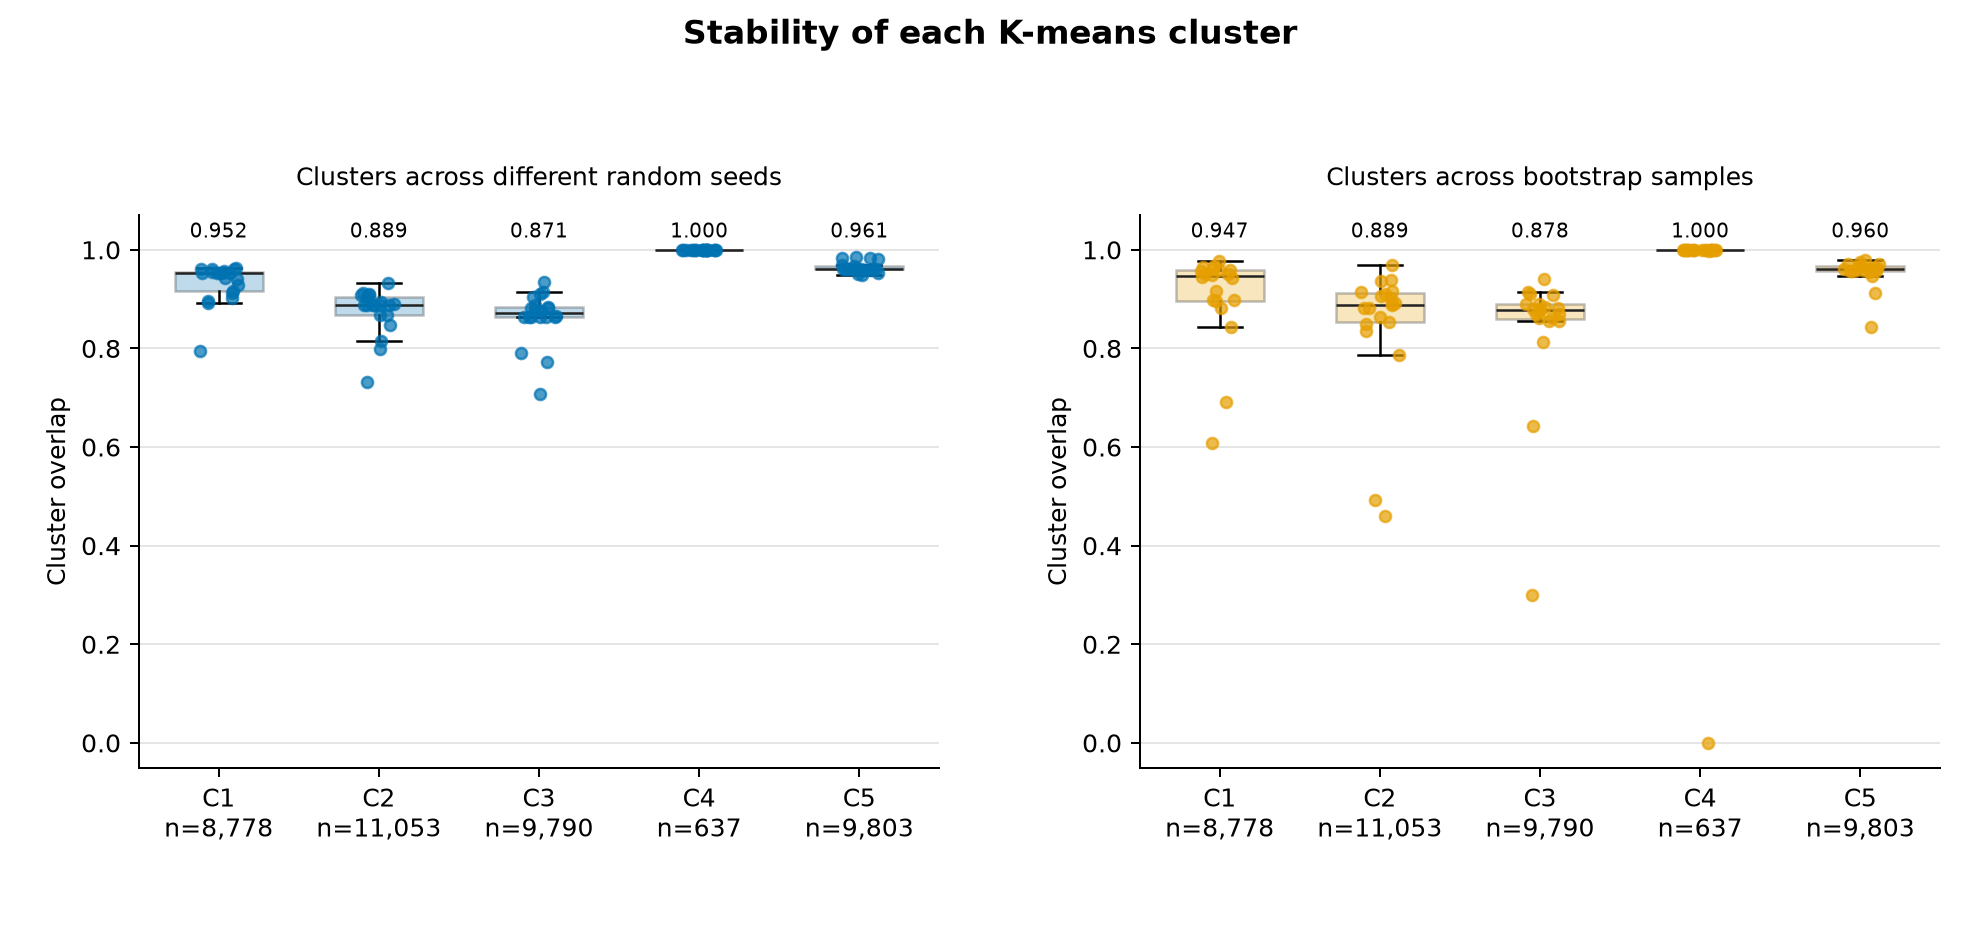

In [9]:
plot_cluster_stability(
    cluster_stability_runs, reference_counts,
    "Stability of each K-means cluster", "step5_kmeans_cluster_stability"
)


In [11]:
worst_bootstrap = stability_runs.loc[
    stability_runs["Experiment"] == "Bootstrap"
].nsmallest(1, "All-respondent ARI")
display(worst_bootstrap.round(4))
worst_bootstrap_run = int(worst_bootstrap["Run"].iloc[0])
display(cluster_stability_runs.loc[
    (cluster_stability_runs["Experiment"] == "Bootstrap") &
    (cluster_stability_runs["Run"] == worst_bootstrap_run)
].round(3))

assignment_consistency = pd.DataFrame({
    name: 100 * labels.eq(reference_labels, axis=0).mean(axis=1)
    for name, labels in stability_labels.items()
})
assignment_consistency["Reference cluster"] = reference_labels
display(assignment_consistency.groupby("Reference cluster", sort=False).agg(
    ["median", "min"]
).round(2))


,Experiment,Run,Model seed,Refit PCA,Training draws,Distinct training respondents,Out-of-bag respondents,Iterations,Reached iteration limit,Occupied training clusters,Retained response variation (%),All-respondent ARI,Out-of-bag ARI
39,Bootstrap,20,215,True,40061,25390,14671,24,False,5,56.3956,0.4698,0.4738


,Experiment,Run,Cluster,Reference respondents,Jaccard,Respondents assigned,Cluster share change (pp),Mean question TV (%),Mean regional share change (pp)
195,Bootstrap,20,1,8778,0.692,8051,1.815,3.348,1.483
196,Bootstrap,20,2,11053,0.459,11332,0.696,7.793,7.589
197,Bootstrap,20,3,9790,0.300,9378,1.028,11.573,9.008
198,Bootstrap,20,4,637,0.998,636,0.002,0.035,0.003
199,Bootstrap,20,5,9803,0.843,10664,2.149,2.491,2.128


Different starts        Bootstrap      
                            median    min    median   min
Reference cluster                                        
3                            100.0    0.0      95.0   0.0
5                            100.0    5.0     100.0   5.0
2                            100.0    0.0     100.0   5.0
1                            100.0    0.0     100.0   0.0
4                            100.0  100.0      95.0  90.0

After running the cells, compare initialization sensitivity with bootstrap sensitivity. Identify which individual clusters persist or change, including the small repeated-answer group. Use the answer-distribution and regional-share changes to assess whether the Step 4 interpretation persists. Explain the limitations of checking one K, one PCA dimension, and 20 repetitions; stability alone does not establish validity.
